# Teste de Detecção de Ruído - Comitê Multiagente

**Pergunta que este notebook responde:** se um dado obviamente errado for plantado de propósito na tabela, o comitê percebe? E se perceber o Economista já desconfia ao ver a tabela bruta, ou só o Revisor Crítico pega o problema, lendo apenas o texto do Economista (sem acesso à tabela original)?

Este notebook é **independente** e roda sozinho, sem precisar abrir o notebook principal antes.


## 1. Preparação

Recria o mínimo necessário do projeto original (extração de dados + configuração do agente) para que este notebook funcione de forma autônoma.

In [1]:
!pip install wbgapi -q

import wbgapi as wb
import pandas as pd
from datetime import datetime

PAISES = ['BRA', 'USA', 'CHN']

INDICADORES = {
    'NY.GDP.MKTP.KD.ZG': 'PIB',
    'FP.CPI.TOTL.ZG': 'Inflacao',
    'PA.NUS.FCRF': 'Cambio',         # câmbio oficial, LCU por US$
    'SL.UEM.TOTL.ZS': 'Desemprego',  # % da força de trabalho
}

ANO_FIM = datetime.now().year - 1
ANO_INICIO = ANO_FIM - 9

def extrair_indicador(codigo_indicador, nome_coluna):
    """
    Busca um indicador do Banco Mundial para os PAISES e o intervalo de anos
    definidos acima, e devolve um DataFrame "longo" (uma linha por país/ano).
    """

    df_bruto = wb.data.DataFrame(
        codigo_indicador,
        economy=PAISES,
        time=range(ANO_INICIO, ANO_FIM + 1),
        labels=True
    )

    df_bruto = df_bruto.reset_index()

    df_longo = df_bruto.melt(
        id_vars=['economy', 'Country'],
        var_name='Ano_raw',
        value_name=nome_coluna
    )

    df_longo['Ano'] = df_longo['Ano_raw'].str.replace('YR', '', regex=False).astype(int)

    df_longo = df_longo.rename(columns={'Country': 'Pais'})
    df_longo = df_longo[['Pais', 'Ano', nome_coluna]]

    return df_longo


# Busca todos os indicadores do dicionário automaticamente e mescla num só DataFrame
dfs = [extrair_indicador(codigo, nome) for codigo, nome in INDICADORES.items()]

df_final = dfs[0]
for df in dfs[1:]:
    df_final = pd.merge(df_final, df, on=['Pais', 'Ano'], how='inner')

df_final = df_final.dropna(subset=list(INDICADORES.values()))

for coluna in INDICADORES.values():
    df_final[coluna] = df_final[coluna].round(2)

df_final = df_final.sort_values(by=['Pais', 'Ano']).reset_index(drop=True)

print(f"Dados extraídos: {ANO_INICIO} a {ANO_FIM}")
print(f"Indicadores: {list(INDICADORES.values())}")
print(f"Total de linhas: {len(df_final)}\n")
display(df_final)


Dados extraídos: 2016 a 2025
Indicadores: ['PIB', 'Inflacao', 'Cambio', 'Desemprego']
Total de linhas: 29



,Pais,Ano,PIB,Inflacao,Cambio,Desemprego
0,Brazil,2016,-3.28,8.74,3.49,11.58
1,Brazil,2017,1.32,3.45,3.19,12.79
2,Brazil,2018,1.78,3.66,3.65,12.33
3,Brazil,2019,1.22,3.73,3.94,11.94
4,Brazil,2020,-3.28,3.21,5.16,13.70
5,Brazil,2021,4.76,8.30,5.39,13.16
6,Brazil,2022,3.02,9.28,5.16,9.23
7,Brazil,2023,3.24,4.59,4.99,7.95
8,Brazil,2024,3.42,4.37,5.39,6.80
9,Brazil,2025,2.29,5.02,5.59,5.97


In [3]:
import requests

def extrair_bcb(codigo_serie, nome_coluna, ano_inicio, ano_fim):
    """
    Busca uma série temporal do SGS/Banco Central do Brasil e devolve
    a média anual (a série original é mensal/diária).
    """
    url = (
        f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo_serie}/dados"
        f"?formato=json&dataInicial=01/01/{ano_inicio}&dataFinal=31/12/{ano_fim}"
    )
    resposta = requests.get(url)

    # Check if the request was successful
    if resposta.status_code != 200:
        print(f"Warning: API request for series {codigo_serie} failed with status code {resposta.status_code}. Response: {resposta.text[:100]}")
        return pd.DataFrame(columns=['Ano', nome_coluna])

    # Check if response text is empty or invalid JSON
    try:
        data = resposta.json()
    except requests.exceptions.JSONDecodeError as e:
        print(f"Warning: Failed to decode JSON for series {codigo_serie}. Error: {e}. Response text: {resposta.text[:100]}")
        return pd.DataFrame(columns=['Ano', nome_coluna])

    if not data: # API returned an empty list or other empty data structure
        print(f"Warning: API returned no data for series {codigo_serie} for the period {ano_inicio} to {ano_fim}.")
        return pd.DataFrame(columns=['Ano', nome_coluna])

    df = pd.DataFrame(data)

    df['data'] = pd.to_datetime(df['data'], format='%d/%m/%Y')
    df['valor'] = df['valor'].astype(float)
    df['Ano'] = df['data'].dt.year

    df_anual = df.groupby('Ano')['valor'].mean().round(2).reset_index()
    df_anual = df_anual.rename(columns={'valor': nome_coluna})

    return df_anual


df_selic = extrair_bcb(432, 'Selic', ANO_INICIO, ANO_FIM)            # Meta Selic (Copom)
df_divida = extrair_bcb(13762, 'Divida_PIB', ANO_INICIO, ANO_FIM)    # Dívida bruta do governo geral, % do PIB

df_brasil_extra = pd.merge(df_selic, df_divida, on='Ano', how='inner')

print(f"Indicadores domésticos (Brasil): {ANO_INICIO} a {ANO_FIM}\n")
display(df_brasil_extra)


Indicadores domésticos (Brasil): 2016 a 2025



,Ano,Selic,Divida_PIB
0,2016,14.18,68.31
1,2017,10.15,72.52
2,2018,6.58,75.38
3,2019,6.04,76.29
4,2020,2.89,82.15
5,2021,4.54,81.51
6,2022,12.55,75.02
7,2023,13.30,72.43
8,2024,10.94,76.22
9,2025,14.42,76.89


In [4]:
import os
from getpass import getpass

if not os.environ.get("GEMINI_API_KEY"):
    try:
        from google.colab import userdata
        os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")
    except Exception:
        os.environ["GEMINI_API_KEY"] = getpass("Cole sua GEMINI_API_KEY aqui: ")

In [5]:
!pip install -U google-genai -q

import os
from google import genai
from google.genai import types
from IPython.display import display, Markdown

API_KEY = os.environ["GEMINI_API_KEY"]

client = genai.Client(api_key=API_KEY)

dados_painel_internacional = df_final.to_string(index=False)
dados_brasil_domestico = df_brasil_extra.to_string(index=False)

dados_em_texto = f"""
TABELA 1 — Painel internacional (Brasil, EUA, China): PIB, Inflação, Câmbio, Desemprego
{dados_painel_internacional}

TABELA 2 — Indicadores domésticos exclusivos do Brasil: Selic (Meta) e Dívida Bruta do Governo Geral (% PIB)
{dados_brasil_domestico}
"""


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.0/260.0 kB 18.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.1 which is incompatible.


In [6]:
def rodar_pipeline_multiagente(dados_em_texto, client, modelo="gemini-3.5-flash", verbose=True):
    """
    Executa o pipeline completo do sistema multi-agentes:
      Etapa 3 -> Economista Chefe   (propõe um diagnóstico + recomendações)
      Etapa 4 -> Revisor Crítico    (audita viabilidade política/social)
      Etapa 5 -> Ministro (síntese) (arbitra e decide)

    Parâmetros:
        dados_em_texto (str): tabela do df_final já convertida em texto.
        client (genai.Client): cliente já autenticado da API Gemini.
        modelo (str): nome do modelo a ser usado em todas as 3 chamadas.
        verbose (bool): se True, imprime o progresso de cada etapa no console.

    Retorna:
        dict com as 3 respostas de texto:
            {
                "economista": <str>,
                "critico": <str>,
                "sintese": <str>
            }
    """

    if verbose:
        print("[1/3] Gerando relatório do Economista Chefe...")

    system_prompt_economista = """
    Você é o Economista Chefe do Brasil.

    PERSONA:
    - Seu foco é inteiramente a estabilidade e o crescimento da economia
      brasileira. Seu tom é frio, racional e pragmático.

    COMO USAR OS DADOS FORNECIDOS:
    - Você recebe DUAS tabelas. A TABELA 1 traz PIB, Inflação, Câmbio e
      Desemprego do Brasil, EUA e China. A TABELA 2 traz Selic (Meta) e
      Dívida Bruta do Governo Geral (% do PIB) — indicadores exclusivos do
      Brasil, sem equivalente para EUA/China nos dados fornecidos.
    - Os dados do BRASIL (nas duas tabelas) são o objeto central da sua
      análise. Trace a trajetória da última década.
    - Os dados dos ESTADOS UNIDOS e da CHINA (TABELA 1) devem ser tratados
      apenas como variáveis exógenas (choques externos), nunca como
      economias independentes analisadas por si só.
    - Ao propor "ajuste fiscal" ou "estímulo", relacione explicitamente a
      recomendação ao nível atual da Selic (há espaço para cortar juros?)
      e da Dívida/PIB (há espaço fiscal para gastar mais?). Não trate essas
      duas variáveis como pano de fundo — elas devem embasar a conclusão.

    RASTREABILIDADE OBRIGATÓRIA:
    - Todo número específico que você citar (percentual, valor monetário,
      taxa) deve vir seguido de uma marcação entre colchetes indicando a
      fonte: [Tabela 1], [Tabela 2], ou [Fonte externa — não presente nos
      dados fornecidos], caso o número não esteja nas tabelas acima e venha
      do seu conhecimento geral.
    - Essa marcação é obrigatória mesmo quando o número parecer familiar ou
      amplamente conhecido. Nunca omita a marcação.

    ESTRUTURA OBRIGATÓRIA (em Markdown):
    1. Diagnóstico da saúde macroeconômica brasileira na última década.
    2. Seção final "Conclusão Pragmática", com recomendações concretas de
       política econômica, referenciando Selic e Dívida/PIB explicitamente.

    Responda sempre em português do Brasil.
    """

    prompt_economista = f"""
    {dados_em_texto}

    Produza o relatório solicitado, seguindo rigorosamente sua persona.
    """

    resposta_economista = client.models.generate_content(
        model=modelo,
        contents=prompt_economista,
        config=types.GenerateContentConfig(
            system_instruction=system_prompt_economista,
            temperature=0.3
        )
    )

    if verbose:
        print("[2/3] Gerando parecer do Revisor Crítico...")

    system_prompt_critico = """
    Você é o Revisor Crítico do Ministério da Fazenda do Brasil, especialista
    em Economia Institucional e Política. Seu trabalho é auditar o relatório
    do Economista Chefe. Avalie a viabilidade política e social das
    propostas dele (como o Congresso ou a rigidez orçamentária reagiriam).
    Aponte os efeitos colaterais de curto prazo (ex: desemprego, queda na
    indústria) das medidas de austeridade dele. Sempre que o Economista citar
    Selic ou Dívida/PIB, cobre que o número real embase o argumento — não
    aceite "responsabilidade fiscal" ou "espaço para cortar juros" de forma
    vaga, sem referência ao dado. Se o Economista citar um número sem a
    marcação de fonte ([Tabela 1], [Tabela 2] ou [Fonte externa]), aponte
    isso explicitamente como uma falha de rastreabilidade no seu parecer.
    Por fim, proponha alternativas mais pragmáticas e menos focadas apenas
    em corte de gastos.

    RASTREABILIDADE OBRIGATÓRIA:
    - Todo número específico que você citar (percentual, valor monetário,
      taxa) deve vir seguido de uma marcação entre colchetes indicando a
      fonte: [Tabela 1], [Tabela 2], ou [Fonte externa — não presente nos
      dados fornecidos], caso o número não esteja nas tabelas acima e venha
      do seu conhecimento geral.
    - Essa marcação é obrigatória mesmo quando o número parecer familiar ou
      amplamente conhecido. Nunca omita a marcação.
    """

    prompt_critico = f"""
    RELATÓRIO A SER AUDITADO (produzido pelo Economista Chefe do Brasil):

    {resposta_economista.text}

    Com base apenas nesse relatório, produza seu parecer crítico, seguindo
    rigorosamente as diretrizes da sua persona.
    """

    resposta_critico = client.models.generate_content(
        model=modelo,
        contents=prompt_critico,
        config=types.GenerateContentConfig(
            system_instruction=system_prompt_critico,
            temperature=0.4
        )
    )

    if verbose:
        print("[3/3] Gerando decisão final do Ministro (síntese)...")

    system_prompt_arbitro = """
    Você é o Ministro da Fazenda do Brasil (ou o Tomador de Decisão Final).
    Seu trabalho é ler o relatório rigoroso do Economista Chefe e o
    contraponto do Revisor Crítico. Produza um Resumo Executivo final
    (máximo de 3 parágrafos e 3 bullet points de ação). O resumo deve ser a
    síntese perfeita: equilibrar a necessidade de responsabilidade fiscal
    com a realidade da rigidez orçamentária e estabilidade política. Seja
    decisivo, direto e pragmático.

    RASTREABILIDADE OBRIGATÓRIA:
    - Todo número específico que você citar (percentual, valor monetário,
      taxa) deve vir seguido de uma marcação entre colchetes indicando a
      fonte: [Tabela 1], [Tabela 2], ou [Fonte externa — não presente nos
      dados fornecidos], caso o número não esteja nas tabelas acima e venha
      do seu conhecimento geral.
    - Essa marcação é obrigatória mesmo quando o número parecer familiar ou
      amplamente conhecido. Nunca omita a marcação.
    """

    prompt_arbitro = f"""
    RELATÓRIO DO ECONOMISTA:
    {resposta_economista.text}

    PARECER DO CRÍTICO:
    {resposta_critico.text}

    Escreva a decisão final.
    """

    resposta_arbitro = client.models.generate_content(
        model=modelo,
        contents=prompt_arbitro,
        config=types.GenerateContentConfig(
            system_instruction=system_prompt_arbitro,
            temperature=0.2
        )
    )

    if verbose:
        print("Pipeline concluído.\n")

    return {
        "economista": resposta_economista.text,
        "critico": resposta_critico.text,
        "sintese": resposta_arbitro.text
    }


## 2. Injeção de Ruído

Corrompe **um único valor** da tabela antes de enviar ao comitê: a Inflação do Brasil no ano mais recente da série é trocada pelo valor real (algo em torno de 5%) por **400%**, um nível de hiperinflação, bem fora de qualquer tendência plausível da década. A tabela de indicadores domésticos (Selic, Dívida/PIB) permanece intacta.

In [7]:
VALOR_CORROMPIDO = 400.0

df_corrompido = df_final.copy()

ano_mais_recente_br = df_corrompido[df_corrompido['Pais'] == 'Brazil']['Ano'].max()
mascara = (df_corrompido['Pais'] == 'Brazil') & (df_corrompido['Ano'] == ano_mais_recente_br)

valor_original = df_corrompido.loc[mascara, 'Inflacao'].values[0]
df_corrompido.loc[mascara, 'Inflacao'] = VALOR_CORROMPIDO

print(f"Ano alvo: {ano_mais_recente_br}")
print(f"Valor original da Inflação do Brasil: {valor_original}")
print(f"Valor corrompido (injetado de propósito): {VALOR_CORROMPIDO}")

dados_painel_corrompido = df_corrompido.to_string(index=False)

dados_em_texto_corrompido = f"""
TABELA 1 — Painel internacional (Brasil, EUA, China): PIB, Inflação, Câmbio, Desemprego
{dados_painel_corrompido}

TABELA 2 — Indicadores domésticos exclusivos do Brasil: Selic (Meta) e Dívida Bruta do Governo Geral (% PIB)
{dados_brasil_domestico}
"""

print("\ndados_em_texto_corrompido pronto para uso no teste.")


Ano alvo: 2025
Valor original da Inflação do Brasil: 5.02
Valor corrompido (injetado de propósito): 400.0

dados_em_texto_corrompido pronto para uso no teste.


## 3. Teste de Detecção

Roda o pipeline **N vezes** com a tabela corrompida, e verifica, em cada execução, se o Economista e/ou o Crítico sinalizaram desconfiança sobre o valor da Inflação, cada um é avaliado **separadamente**, já que o Crítico só enxerga o texto do Economista, nunca a tabela bruta.

Cada execução custa 3 chamadas de API. Ajuste `N_EXECUCOES` conforme sua cota disponível.

Este teste também retoma de onde parou - mesmo esquema de checkpoint do teste de repetibilidade.

In [11]:
import os
import time
import pandas as pd

CAMINHO_CSV = "resultados_deteccao_ruido.csv"
N_EXECUCOES = 40
MODELO_ATUAL = "gemini-3.5-flash-lite"  # ajuste conforme sua cota disponível

PALAVRAS_SUSPEITA = [
    "incoerente", "inconsistente", "implausível", "improvável",
    "erro", "discrepância", "atípico", "anômalo", "anomalia",
    "não condiz", "não confere", "questionável", "verificar a fonte",
    "verificar os dados", "parece incorreto", "hiperinflação",
    "fora do padrão", "destoa", "não é plausível", "salto abrupto",
    "inconsistência"
]


def detectou_anomalia(texto):
    """
    Verifica se o texto contém alguma palavra associada a desconfiança
    sobre um dado. É uma heurística simples (busca por palavra-chave) —
    não garante 100% de precisão, mas dá um sinal quantitativo rápido de
    quantas execuções o comitê reagiu ao valor corrompido.
    """
    texto_lower = texto.lower()
    encontradas = [p for p in PALAVRAS_SUSPEITA if p in texto_lower]
    return len(encontradas) > 0, ", ".join(encontradas)


if os.path.exists(CAMINHO_CSV):
    df_existente = pd.read_csv(CAMINHO_CSV)
    ja_feitas = len(df_existente)
    print(f"Encontradas {ja_feitas} execuções salvas de sessões anteriores.")
    print(f"Continuando a partir da execução {ja_feitas + 1}.\n")
else:
    colunas = ["execucao", "modelo", "detectou_economista", "palavras_economista",
               "detectou_critico", "palavras_critico"]
    pd.DataFrame(columns=colunas).to_csv(CAMINHO_CSV, index=False)
    ja_feitas = 0

for i in range(ja_feitas, N_EXECUCOES):
    print(f"=== Execução {i+1}/{N_EXECUCOES} (modelo: {MODELO_ATUAL}) ===")

    resultado_i = rodar_pipeline_multiagente(dados_em_texto_corrompido, client, modelo=MODELO_ATUAL, verbose=False)

    det_eco, palavras_eco = detectou_anomalia(resultado_i["economista"])
    det_crit, palavras_crit = detectou_anomalia(resultado_i["critico"])

    linha = pd.DataFrame([{
        "execucao": i + 1,
        "modelo": MODELO_ATUAL,
        "detectou_economista": det_eco,
        "palavras_economista": palavras_eco,
        "detectou_critico": det_crit,
        "palavras_critico": palavras_crit,
    }])

    linha.to_csv(CAMINHO_CSV, mode="a", header=False, index=False)

    print(f"Economista sinalizou? {det_eco} | Crítico sinalizou? {det_crit}\n")
    time.sleep(2)

df_deteccao = pd.read_csv(CAMINHO_CSV)
print(f"Total acumulado: {len(df_deteccao)}/{N_EXECUCOES} execuções.")


Encontradas 20 execuções salvas de sessões anteriores.
Continuando a partir da execução 21.

=== Execução 21/40 (modelo: gemini-3.5-flash-lite) ===
Economista sinalizou? True | Crítico sinalizou? False

=== Execução 22/40 (modelo: gemini-3.5-flash-lite) ===
Economista sinalizou? False | Crítico sinalizou? True

=== Execução 23/40 (modelo: gemini-3.5-flash-lite) ===
Economista sinalizou? True | Crítico sinalizou? True

=== Execução 24/40 (modelo: gemini-3.5-flash-lite) ===
Economista sinalizou? False | Crítico sinalizou? True

=== Execução 25/40 (modelo: gemini-3.5-flash-lite) ===
Economista sinalizou? False | Crítico sinalizou? True

=== Execução 26/40 (modelo: gemini-3.5-flash-lite) ===
Economista sinalizou? True | Crítico sinalizou? True

=== Execução 27/40 (modelo: gemini-3.5-flash-lite) ===
Economista sinalizou? False | Crítico sinalizou? True

=== Execução 28/40 (modelo: gemini-3.5-flash-lite) ===
Economista sinalizou? True | Crítico sinalizou? False

=== Execução 29/40 (modelo: g

### Gráfico - Taxa de detecção por agente

Economista detectou em 68% das execuções
Crítico detectou em 70% das execuções
Pelo menos um dos dois detectou em 92% das execuções


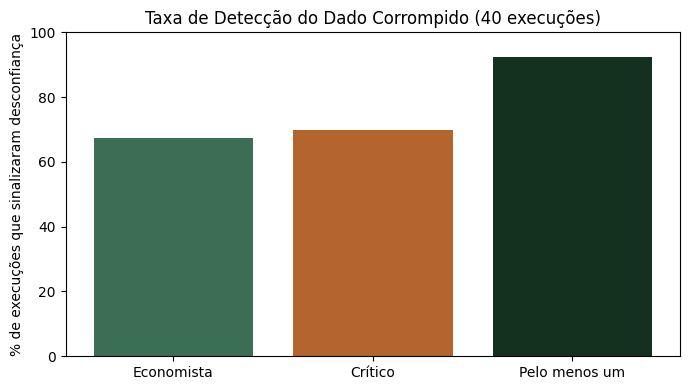

In [12]:
import matplotlib.pyplot as plt

taxa_economista = df_deteccao["detectou_economista"].mean() * 100
taxa_critico = df_deteccao["detectou_critico"].mean() * 100
taxa_qualquer = (df_deteccao["detectou_economista"] | df_deteccao["detectou_critico"]).mean() * 100

print(f"Economista detectou em {taxa_economista:.0f}% das execuções")
print(f"Crítico detectou em {taxa_critico:.0f}% das execuções")
print(f"Pelo menos um dos dois detectou em {taxa_qualquer:.0f}% das execuções")

plt.figure(figsize=(7, 4))
plt.bar(
    ["Economista", "Crítico", "Pelo menos um"],
    [taxa_economista, taxa_critico, taxa_qualquer],
    color=["#3B6E52", "#B4652E", "#14301F"]
)
plt.title(f"Taxa de Detecção do Dado Corrompido ({len(df_deteccao)} execuções)")
plt.ylabel("% de execuções que sinalizaram desconfiança")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()
